In [4]:
import os

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable 

# Following options are dependant on https://github.com/chanjure/global_chanju.git
# However, this is just an aesthetic package for plotting, so it is not necessary.
from global_chanju.paulplot.styles import nice_style
from global_chanju.paulplot.rc_setter import set_rc
from global_chanju.paulplot.rc_setter import get_rc

set_rc() # Setting global chanju plotting scheme

# Optimal stepsize in non-linear models

In [5]:
# Image saving directory
plot_dir = "../images/optimal_stepsize/"
os.system("mkdir -p "+plot_dir)

0

\begin{align}
    \mu_{2,a} &= \mathbb{E}_{x} \left[ \left( \sigma'(h) \right)^2 + \left( \sigma(h) - \sigma(h^{\ast}) \right) \sigma''(h) \right]
\end{align}

For $\sigma(x) = \tanh (x)$, using

\begin{align}
    \tanh'(x) &= 1 - \tanh^2(x) \\
    \tanh''(x) &= 2 \tanh^3(x) - 2 \tanh(x),
\end{align}

\begin{align}
    \mu_{2,a} &= \mathbb{E}_{x} \left[ 3 \tanh^4(h) - 2 \tanh (h^{\ast}) \tanh^3(h) - 4 \tanh^2(h) + 2\tanh(h^{\ast}) \tanh(h) +1 \right] \\
    \mu_{2} &\equiv \mathbb{E}_{W_a}\left[ \mu_{2,a} \right]
\end{align}

For $\sigma(x) = \mbox{ReLU}(x)$,

\begin{align}
    \mbox{ReLU}'(x) &= \theta(x) \\
    \mbox{ReLU}''(x) &= 0,
\end{align}

\begin{align}
    \mu_{2,a} = \mathbb{E}_{x} \left[\theta(h)^2 \right]
\end{align}

where $h_a = (Wx)_a$, $W \sim \mathcal{N}(0,\sigma^2)$.

In [96]:
def mu_2a_tanh(sigma, n=1000, M=100, N=200):
    """ mu2 value for hyperbolic tangent
    """
    x = np.random.normal(0, 1, size=(n, N)) # data
    
    Wt = np.zeros((M, N))
    Wt[0][0] = 1 # rank-1 Teacher matrix
    
    W = np.random.normal(0, sigma / np.sqrt(N), size=(n, M, N)) # Student distribution
    
    h = np.einsum("nMN, nN -> nM", W, x)
    ht = np.einsum("MN, nN -> nM", Wt, x)
    
    return 3.*np.tanh(h)**4 - 2.*np.tanh(ht) * np.tanh(h)**4 - 4.*np.tanh(h)**2 + 2.*np.tanh(ht)*np.tanh(h) + 1

def mu_2a_relu(sigma, n=1000, M=100, N=200):
    """ mu2 value for ReLU activation
    """
    x = np.random.normal(0, 1, size=(n, N)) # data
     
    W = np.random.normal(0, sigma / np.sqrt(N), size=(n, M, N)) # Student
    
    h = np.einsum("nMN, nN -> nM", W, x) # The output does not depend on W^*
    
    return np.heaviside(h, 0)**2

def mu_2a_tanh_short(sigma, n=1000, M=100, N=200):
    """
    Same as mu_2a_tanh, but using Gaussian equivalence thm.
    """
    x = np.random.normal(0, 1, size=(n, N))
    Wt = np.zeros((M, N))
    Wt[0][0] = 1
#     W = np.random.normal(0, sigma / np.sqrt(N), size=(n, M, N))
    h = np.random.normal(0, sigma, size=(n, M))
    ht = np.einsum("MN, nN -> nM", Wt, x)
    return 3.*np.tanh(h)**4 - 2.*np.tanh(ht) * np.tanh(h)**4 - 4.*np.tanh(h)**2 + 2.*np.tanh(ht)*np.tanh(h) + 1

In [7]:
n_x = 30 # number of sigma points
sig_list = np.logspace(-2, 2, n_x) # Same sigma range as in phase transition paper
mu_tanh_list = np.array(list(map(mu_2a_tanh, sig_list))) # 1000 data for each sigma
mu_relu_list = np.array(list(map(mu_2a_relu, sig_list))) # 1000 data for each sigma

In [8]:
mu_tanh_mean = np.mean(mu_tanh_list, axis=(-1, -2))
mu_relu_mean = np.mean(mu_relu_list, axis=(-1,-2))

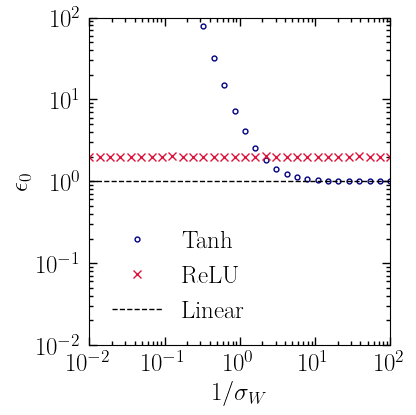

In [9]:
n_fig = 1
fig_width = get_rc()['W']
fig_scale = get_rc()['r']
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*fig_width*fig_scale, fig_width*fig_scale)) # Square figure

# optimal epsilon = 1./mu
axs.plot(1./sig_list, 1./mu_tanh_mean, ls='', marker='.', color='navy', label=r"Tanh")
axs.plot(1./sig_list, 1./mu_relu_mean, ls='', marker='x', color='crimson', label=r"ReLU", markersize=6)

# For linear model
axs.axhline(1., ls="--", color='k', label=r"Linear")

# global_cj setting
nice_style(axs, 
           xlim=(1e-2, 1e2), ylim=(1e-2, 1e2),
           xlabel=r"$1/\sigma_W$", ylabel=r"$\epsilon_0$",
           logx=True, logy=True
          )

plt.legend(loc='lower left')

plt.tight_layout()

plt.savefig(plot_dir+"optimal_eps.pdf")
plt.show()

The $\epsilon_0$ is the maximum convergent stepsize.

\begin{align}
    (1 - \epsilon \mu_2 )^2 \le 1 \ \Rightarrow \ \epsilon \le \frac{1}{\mu_2}
\end{align}

Above this value, the initial bulk increases instead.

# Numerical test

The model

\begin{align}
    \hat y = \sigma (W x), \quad y = \sigma (W^{\ast} x)
\end{align}

Quadratic loss and gradient

\begin{align}
    \ell (y, \hat y) = \frac{1}{2} \mathbb{E}_{x} \left( y - \hat y \right) \left( y - \hat y \right)^T,
    \quad
    \partial_{W} \ell = - (y - \hat y) \, \sigma' x
\end{align}

In [10]:
N = 100
M = 200
r = N/M

epochs = 2

n_try = 1000
n_data = 3000

epsilon_list = np.logspace(-2, 2, 10)
sigma_list = np.logspace(-2, 2, 10)

data_dir = "../data/optimal_stepsize/"
os.system("mkdir -p "+data_dir)

0

In [11]:
def simulate(epsilon, sigma):
    # Load or generate data
    data_string = "N%d_r%.2f_eps%.5f_sig%.5f"%(N, r, epsilon, sigma)
    print(data_string)

    if data_string+"_data.npz" in os.listdir(data_dir):
        load = True
        print("Load data from "+data_dir+data_string+"_data.npz")
    else:
        load = False

    W_star = np.zeros((N,M))
    W_star[0][0] = 1
    README = ""

    if load:
        data = np.load(data_dir+data_string+"_data.npz")
        README = data["README"]
        W_list = data["W_list"]
        l_list = data["l_list"]

        print("Data loaded from: "+data_dir+data_string+"_data.npz")
    else:
        print("Generating ... ")
        W_list = np.zeros((n_try, epochs+1, N, M))
        l_list = np.zeros((n_try, epochs+1))

        for n in range(n_try):
            data = np.random.normal(0., 1., size=(n_data, M))
            W0 = np.random.normal(0., sigma/np.sqrt(M), size=(N,M))

            W_list[n][0] = W0.copy()

            W_ = W0.copy() # N x M

            h_hat = data @ W_.T # n x M

            y_hat = np.tanh(h_hat) # n x M
            y = np.tanh(data @ W_star.T) # n x M

            l_ = 0.5*np.trace((y - y_hat) @ (y - y_hat).T)/n_data

            l_list[n][0] = l_.copy()
            
            for e in range(epochs):

                dl = - np.mean(np.einsum("nM, nN, nN -> nNM", data, y - y_hat, np.ones_like(h_hat) - np.tanh(h_hat)**2), axis=0)

                W_ = W_ - epsilon * dl

                W_list[n][e+1] = W_.copy()

                h_hat = data @ W_.T # n x M

                y_hat = np.tanh(h_hat) # n x M
                y = np.tanh(data @ W_star.T) # n x M

                l_ = 0.5*np.trace((y - y_hat) @ (y - y_hat).T)/n_data

                l_list[n][e+1] = l_.copy()

        README = """
        N: %d
        M: %d
        r: %.4f
        eps: %.4f
        sig: %.4f
        epochs: %d
        n_try: %d
        """%(N, M, r, epsilon, sigma, epochs, n_try)

        np.savez(data_dir+data_string+"_data.npz",
                 README = README,
                 W_list = W_list, 
                 l_list = l_list,
                )

        print("Data saved to "+data_dir+data_string+"_data.npz")

    print(README)
    
    l_ratio = l_list[1]/l_list[0]
    l_mean = np.mean(l_ratio, axis=0)
    l_std = np.std(l_ratio, axis=0)
    
    l_diff = (l_list[1] - l_list[0]) / l_list[0] # Normalise to 1
    l_diff_mean = np.mean(l_diff, axis=0)
    l_diff_std = np.std(l_diff, axis=0)

    print(l_mean, l_std)

    with open(data_dir+"l_list.txt", "a") as text_file:
        text_file.write("%.5f,%.5f,%.5f,%.5f,%.5f,%.5f\n" % (epsilon, sigma, l_mean, l_std, l_diff_mean, l_diff_std))

In [12]:
# Generate single step trained networks

# os.system("rm "+data_dir+"l_list.txt")
# for epsilon in epsilon_list:
#     for sigma in sigma_list:
#         simulate(epsilon, sigma)

In [13]:
with open(data_dir+"l_list.txt") as f:
    data_all = f.read()
    
loss_data = data_all.split("\n")[:-1]

X, Y = np.meshgrid(sigma_list, epsilon_list)
Z = np.zeros((len(epsilon_list), len(sigma_list)))
Zs = np.zeros((len(epsilon_list), len(sigma_list)))
C = np.zeros((len(epsilon_list), len(sigma_list)))
Cs = np.zeros((len(epsilon_list), len(sigma_list)))

for s in loss_data:
    yi, xi, zi, zis, ti, tis = np.array(s.split(','), dtype=float)
    x_index = np.where(np.isclose(sigma_list, xi, rtol=1e-3))[0][0]
    y_index = np.where(np.isclose(epsilon_list, yi, rtol=1e-3))[0][0]
    Z[y_index, x_index] = zi
    Zs[y_index, x_index] = zis
    C[y_index, x_index] = ti
    Cs[y_index, x_index] = tis

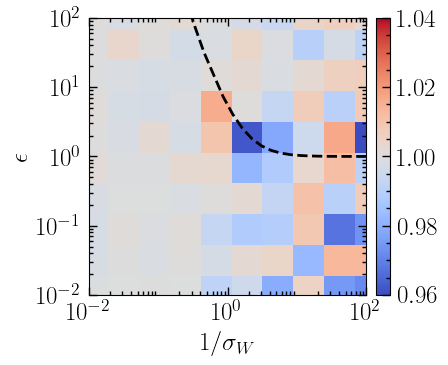

In [95]:
set_rc(scale=1)

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

im = axs.pcolormesh(1./X, Y, Z,
                    vmin=0.96, vmax=1.04,
                    cmap='coolwarm',
                    shading='auto')

axs.plot(1./sig_list[:-9], 1./mu_tanh_mean[:-9], 
         ls='--', marker='', color='k', lw=2,
         label=r"Tanh")

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir + "loss.pdf", bbox_inches="tight")

plt.show()

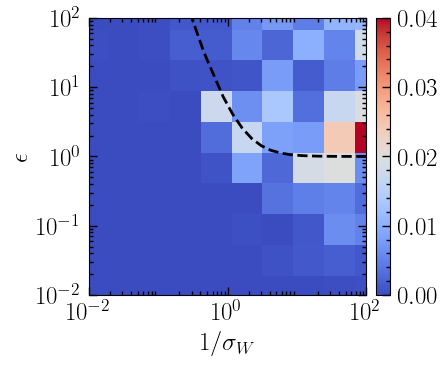

In [134]:
set_rc(scale=1)

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

im = axs.pcolormesh(1./X, Y, Zs,
                    vmin=0., vmax=0.04,
                    cmap='coolwarm',
                    shading='auto')

axs.plot(1./sig_list[:-9], 1./mu_tanh_mean[:-9], 
         ls='--', marker='', color='k', lw=2,
         label=r"Tanh")

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir + "loss_fluc.pdf", bbox_inches="tight")

plt.show()

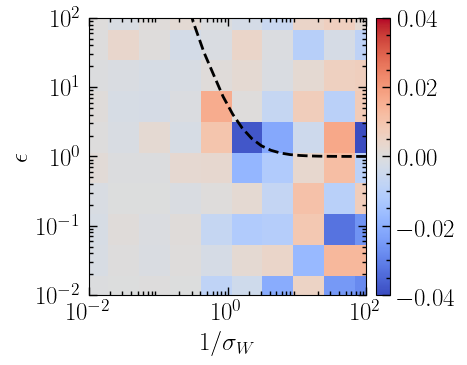

In [133]:
set_rc(scale=1)

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

im = axs.pcolormesh(1./X, Y, C,
                    vmin=-0.04, vmax=0.04,
                    cmap='coolwarm',
                    shading='auto')

axs.plot(1./sig_list[:-9], 1./mu_tanh_mean[:-9], 
         ls='--', marker='', color='k', lw=2,
         label=r"Tanh")

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir + "loss_diff.pdf", bbox_inches="tight")

plt.show()

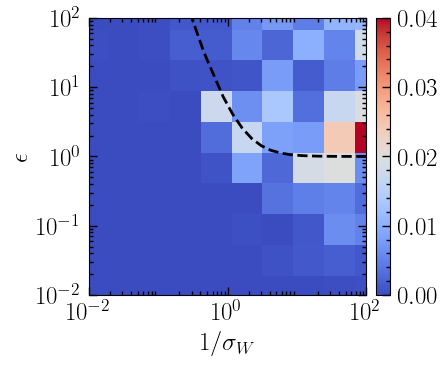

In [132]:
set_rc(scale=1)

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

im = axs.pcolormesh(1./X, Y, Cs,
                    vmin=0., vmax=0.04,
                    cmap='coolwarm',
                    shading='auto')

axs.plot(1./sig_list[:-9], 1./mu_tanh_mean[:-9], 
         ls='--', marker='', color='k', lw=2,
         label=r"Tanh")

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir + "loss_diff_fluc.pdf", bbox_inches="tight")

plt.show()

# BBP in Non-linear models

Using the modified first step update equation (82),

\begin{align}
    X_{ab}' \simeq (1 - \epsilon \mu_2)^2 X_{ab} + \epsilon^2 \mu_1^2 X_{ab}^{\ast},
\end{align}

where $\mu_{1,2}$ are ensemble averaged value, the location of isolated eigenvalue and the critical stepsize is obtained by substituting

\begin{align}
    (1 - \epsilon) \sigma_W \to (1 - \mu_2 \epsilon) \sigma_W,
    \quad
    \epsilon^2 \lambda^{\ast} \to \mu_1^2 \epsilon^2 \lambda^{\ast},
\end{align}

in equations (27, 28).

Then the location of the isolated eigenvalue and critical step size is given as,

\begin{align}
    \lambda^{\rm iso} &= \mu_1^2 \epsilon^2 \lambda^{\ast}
    \left[ 1 + \frac{(1 - \mu_2 \epsilon)^2 \sigma_W^2}{\mu_1^2 \epsilon^2 \lambda^{\ast} - r (1 - \mu_2 \epsilon)^2 \sigma_W^2} \right], \\
    \epsilon_c &= \frac{\mu_2 \sigma_W^2 R - \sqrt{\mu_1^2 \lambda^{\ast} \sigma_W^2 R}}{\mu_2^2 \sigma_W^2 R - \mu_1^2 \lambda^{\ast}}, \quad R \equiv \sqrt{r} + r.
\end{align}

In [109]:
def mu_1a_tanh(sigma, n=1000, N=100, M=200):
    x = np.random.normal(0, 1, size=(n, M))
    Wt = np.zeros((N, M))
    Wt[0][0] = 1
    
    h = np.random.normal(0, sigma, size=(n, N))
    ht = np.einsum("NM, nM -> nN", Wt, x)
    return np.mean((np.ones_like(ht) - np.tanh(ht)**2) * (np.ones_like(h) - np.tanh(h)**2))

def mu_2a_tanh(sigma, n=1000, N=100, M=200):
    """
    Same as mu_2a_tanh, but using Gaussian equivalence thm.
    """
    x = np.random.normal(0, 1, size=(n, M))
    Wt = np.zeros((N, M))
    Wt[0][0] = 1
#     W = np.random.normal(0, sigma / np.sqrt(N), size=(n, M, N))
    h = np.random.normal(0, sigma, size=(n, N))
    ht = np.einsum("NM, nM -> nN", Wt, x)
    return np.mean(3.*np.tanh(h)**4 - 2.*np.tanh(ht) * np.tanh(h)**4 - 4.*np.tanh(h)**2 + 2.*np.tanh(ht)*np.tanh(h) + 1)

def lambda_iso(sigma, epsilon, r=0.5):
    mu1 = mu_1a_tanh(sigma)
    mu2 = mu_2a_tanh(sigma)
    
    A = mu1**2 * epsilon**2 
    B = (1. - mu2 * epsilon)**2 * sigma**2
    C = mu1**2 * epsilon**2 - r * (1. - mu2 * epsilon)**2 * sigma**2
    return A * (1. + B/C)

def epsilon_c(sigma, r=0.5):
    mu1 = mu_1a_tanh(sigma)
    mu2 = mu_2a_tanh(sigma)
    R = np.sqrt(r) + r
    
    A = mu2 * sigma**2 * R - np.sqrt(mu1**2 * sigma**2 * R)
    B = mu2**2 * sigma**2 * R - mu1**2
    return A/B

In [110]:
epsilon_c_list = np.array(list(map(epsilon_c, sigma_list)))

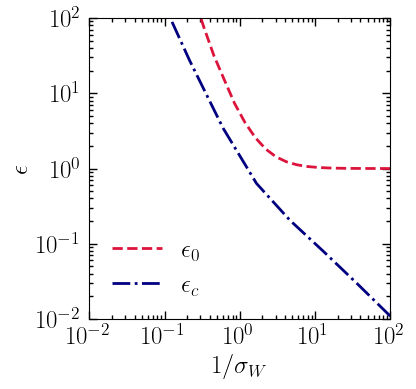

In [120]:
set_rc(scale=1)

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

# im = axs.pcolormesh(1./X, Y, Z,
#                     vmin=0.96, vmax=1.04,
#                     cmap='coolwarm',
#                     shading='auto')

axs.plot(1./sig_list[:-9], 1./mu_tanh_mean[:-9], 
         ls='--', marker='', color='crimson', lw=2,
         label=r"$\epsilon_0$")

axs.plot(1./sigma_list, epsilon_c_list,
         ls='-.', marker='', color='navy', lw=2,
         label=r"$\epsilon_c$")

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

# divider = make_axes_locatable(axs)
# cax = divider.append_axes("right", size="5%", pad=0.1)

# cb = fig.colorbar(im, cax=cax)
plt.legend(loc='lower left')

plt.savefig(plot_dir + "bbp_op_lines.pdf", bbox_inches="tight")

plt.show()

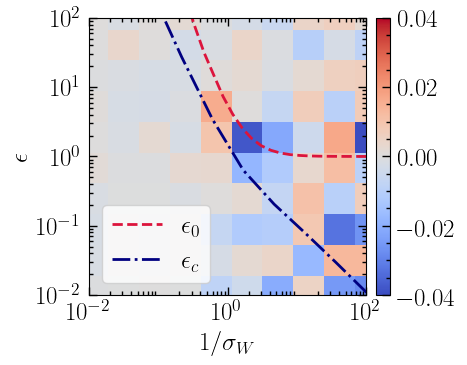

In [146]:
set_rc(scale=1)

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

im = axs.pcolormesh(1./X, Y, C,
                    vmin=-0.04, vmax=0.04,
                    cmap='coolwarm',
                    shading='auto')

axs.plot(1./sig_list[:-9], 1./mu_tanh_mean[:-9], 
         ls='--', marker='', color='crimson', lw=2,
         label=r"$\epsilon_0$")

axs.plot(1./sigma_list, epsilon_c_list,
         ls='-.', marker='', color='navy', lw=2,
         label=r"$\epsilon_c$")

plt.legend(loc='lower left', facecolor='white', framealpha=0.8, frameon=1)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir + "bbp_op_lines_loss.pdf", bbox_inches="tight")

plt.show()

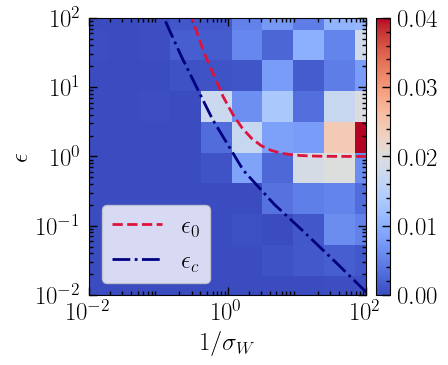

In [144]:
set_rc(scale=1)

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

im = axs.pcolormesh(1./X, Y, Cs,
                    vmin=0., vmax=0.04,
                    cmap='coolwarm',
                    shading='auto')

axs.plot(1./sig_list[:-9], 1./mu_tanh_mean[:-9], 
         ls='--', marker='', color='crimson', lw=2,
         label=r"$\epsilon_0$")

axs.plot(1./sigma_list, epsilon_c_list,
         ls='-.', marker='', color='navy', lw=2,
         label=r"$\epsilon_c$")

plt.legend(loc='lower left', facecolor='white', framealpha=0.8, frameon=1)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir + "bbp_op_lines_loss_fluc.pdf", bbox_inches="tight")

plt.show()